# Overhead analysis
This notebook generates the plots necessary to understand the overhead caused by CodeCarbon and the resource measurements. 

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np
import glob

In [2]:
batch_sizes = (32, 64, 128)
modes = ('onfly', 'preload')
mode_labels = {"onfly": "on-the-fly", "preload":"before training"}

exp_labels = {"e2e_train": "End-to-end training time",
         "e2e_cc": "End-to-end CodeCarbon",
         "fine_cc": "Fine-grained CodeCarbon",
         "resource_phase": "Fine-grained compute"}

In [3]:
data_dir = os.path.join(os.getcwd(), 'final_data_analysis')
plot_dir = os.path.join(os.getcwd(), 'final_plots', 'overhead')

Get the files necessary

In [4]:
# files for E2E training
data_e2e_train = glob.glob(os.path.join(data_dir, "overhead", "e2e", "*.csv"))

# files for E2E CodeCarbon
data_e2e_cc = glob.glob(os.path.join(data_dir, "overhead", "e2e_cc", "*.csv"))

# files for finegrain CodeCarbon
data_fine_cc = glob.glob(os.path.join(data_dir, "overhead", "fine_cc", "*.csv"))

# files for compute phase
data_resource_phase = glob.glob(os.path.join(data_dir, "overhead", "resource_phase", "*.csv"))

files = {"e2e_train": data_e2e_train,
         "e2e_cc": data_e2e_cc,
         "fine_cc": data_fine_cc,
         "resource_phase": data_resource_phase}

In [5]:
len(data_e2e_train), len(data_e2e_cc), len(data_fine_cc), len(data_resource_phase)

(18, 18, 18, 17)

In [6]:
def get_params_from_filename(file):
    """
    Inputs:
        file: str, full file path
    Outputs:
        batch_size: int
        num_workers: int
        num_samples: int
        repeat: int
    """
    file_name = os.path.basename(file)
    
    batch_size = int(file_name.split("_batch-")[1].split("_work-")[0])
    num_workers = int(file_name.split("_work-")[1].split("_samples-")[0])
    num_samples = int(file_name.split("_samples-")[1].split("_repeat-")[0])
    repeat = int(file_name.split("_repeat-")[1].split("_labels-")[0])
    total_samples = num_samples * repeat
    mode = file_name.split("_")[-1].split(".csv")[0]

    return batch_size, num_workers, total_samples, mode

In [7]:
def create_e2e_df(files_list):
    """
    Inputs:
        files_list: list of file_names containing timing data for one E2E experiment
    Outputs:
        df_e2e: dataframe with information about E2E timing, batch size, num workers, num samples, and mode
    """
    batch_sizes_list = []
    num_workers_list = []
    num_samples_list = []
    modes_list = []

    df_e2e = pd.DataFrame()

    for file in files_list:
        df = pd.read_csv(file)

        # get params
        batch_size, num_workers, total_samples, mode = get_params_from_filename(file)

        # fill lists
        batch_sizes_list.append(batch_size)
        num_workers_list.append(num_workers)
        num_samples_list.append(total_samples)
        modes_list.append(mode)

        # add the time data
        df_e2e = pd.concat([df_e2e, df], ignore_index=True)

    df_e2e["batch_size"] = batch_sizes_list
    df_e2e["num_workers"] = num_workers_list
    df_e2e["num_samples"] = num_samples_list
    df_e2e["mode"] = modes_list

    # convert to ms
    df_e2e["time"] = df_e2e["time"]/1e6
    return df_e2e

Merge the files into one dataframe

In [8]:
data = {}
for exp in files:
    data[exp] = create_e2e_df(files[exp])
    data[exp].to_csv(os.path.join(data_dir, "overhead", f"{exp}.csv"), index=False)

Plot the overhead - one plot per mode

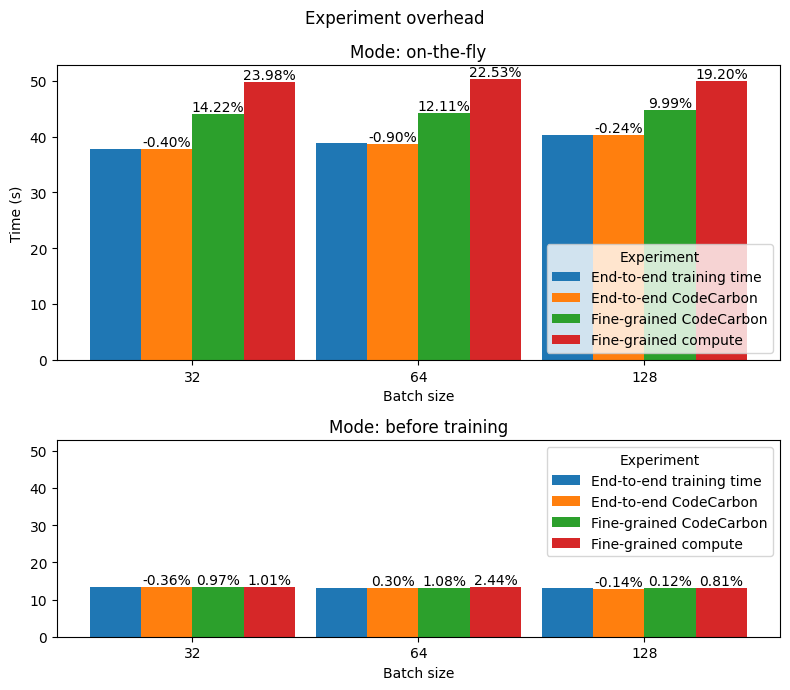

In [9]:
fig, ax = plt.subplots(2, 1, sharey=True, figsize=(8, 7), layout="tight",gridspec_kw={'height_ratios': [1.5, 1]})

label_locs = np.arange(len(batch_sizes))*1.1  # the label locations
width = 0.25  # the width of the bars

for i, mode in enumerate(modes):
    bar_time_data = {}  # {experiment: [mean 32, mean 64, mean 128]}

    for exp in data:
        data_per_mode_train = data[exp][data[exp]["mode"]==mode]
        bar_time_data[exp] = data_per_mode_train.groupby("batch_size")["time"].mean()/1e3
    
    multiplier = 0
    for attribute, measurement in bar_time_data.items():
        offset = multiplier * width
        rects = ax[i].bar(label_locs + offset, measurement, width, label=exp_labels[attribute])
        multiplier += 1

        if attribute != "e2e_train":
            # calculate percent diff
            percent_diff = 100*(1 - bar_time_data["e2e_train"]/measurement)
            percent_diff = [f"{diff:.2f}%" for diff in percent_diff]
            ax[i].bar_label(rects, labels=percent_diff)
            #ax[i].bar_label(rects)

    ax[i].set_xticks(label_locs+1.5*width, batch_sizes)
    ax[i].set_xlabel("Batch size")
    ax[i].set_title(f"Mode: {mode_labels[mode]}")
    ax[i].legend(title="Experiment", loc="lower right")

ax[0].set_ylabel("Time (s)")
ax[1].legend(title="Experiment", loc="upper right")
fig.suptitle("Experiment overhead")

fig.savefig(os.path.join(plot_dir, "overhead_all.png"), dpi=300, bbox_inches="tight")